# Representation Learning With PCA and Autoencoders

---

**Group Number: 123**

| # | Student Name | Email |
|---|------|-------|
| 1 | Agarwal Rankit Atulkumar | 2025ab05296@wilp.bits-pilani.ac.in |
| 2 | Nishant Verma | 2025aa05051@wilp.bits-pilani.ac.in |
| 3 | Aryasomayajula Subrahmanya Srinivas | 2025aa05539@wilp.bits-pilani.ac.in |
| 4 | Wali Haider | 2025ab05295@wilp.bits-pilani.ac.in |
| 5 | Amit Mallikarjun Masuti | 2024ac05742@wilp.bits-pilani.ac.in |

---


This improved notebook solves the assignment tasks for MNIST and CIFAR10 converted to gray level.

Requirements implemented:

- MNIST and CIFAR10 loaded from `tensorflow.keras.datasets`
- CIFAR10 converted to gray level
- both datasets resized to 28 x 28
- intensities rescaled to [50, 200]
- random 70% / 20% / 10% train / validation / test split
- standard PCA and randomized PCA with 30 components
- logistic regression classification on PCA features and autoencoder features
- multiclass ROC curves
- reconstruction SNR in dB using the explicit per-image formula
- exact 70% / 20% / 10% split counts
- validation-tuned logistic regression regularization
- tied-weight linear autoencoder with unit-magnitude encoder vectors, PCA initialization, and orthogonality penalty
- component/weight visualization and quantitative PCA-AE comparison in both raw and standardized spaces
- deep convolutional autoencoder with 30-dimensional latent space
- single hidden layer and three hidden layer dense autoencoder comparisons

Before running:

```python
# Uncomment if your environment is missing packages.
# %pip install -q tensorflow scikit-learn matplotlib pandas seaborn
```



**Improvements in this `wali` version.**

- Task 2 now compares the tied linear AE against PCA fitted in the same standardized space used by the AE.
- The original Task 1 PCA comparison is still retained for traceability.
- Top-30 eigenvalue tables are displayed separately to avoid notebook/PDF truncation.
- Logistic regression uses the validation split to select `C` before test evaluation.
- The final interpretation no longer treats a PCA-AE mismatch as a successful subspace recovery.


In [ ]:
import os
import socket
import random
from datetime import datetime
import warnings
from dataclasses import dataclass

# Keep Matplotlib cache inside a writable location when running from managed kernels.
os.environ.setdefault("MPLCONFIGDIR", os.path.join("/tmp", "matplotlib"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import sklearn
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize, StandardScaler

from scipy.optimize import linear_sum_assignment

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")



## Configuration

`FAST_MODE=False` runs the full 70/20/10 split required by the assignment.
If you only want to verify that the notebook executes, set `FAST_MODE=True`.



In [ ]:
RANDOM_SEED = 42
FAST_MODE = False

N_COMPONENTS = 30
IMAGE_SHAPE = (28, 28)
N_CLASSES = 10
LOGISTIC_C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]

BATCH_SIZE = 256
LINEAR_AE_EPOCHS = 150
DENSE_AE_EPOCHS = 60
CONV_AE_EPOCHS = 50
PATIENCE = 12

if FAST_MODE:
    # Small values for quick testing only. Leave FAST_MODE=False for submission runs.
    MAX_TOTAL_PER_DATASET = 12000
    LINEAR_AE_EPOCHS = 10
    DENSE_AE_EPOCHS = 8
    CONV_AE_EPOCHS = 8
else:
    MAX_TOTAL_PER_DATASET = None

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow:", tf.__version__)
print("scikit-learn:", sklearn.__version__)
print("FAST_MODE:", FAST_MODE)
gpus = tf.config.list_physical_devices("GPU")
print("GPU devices:", gpus)
for gpu in gpus:
    details = tf.config.experimental.get_device_details(gpu)
    print("GPU name:", details.get("device_name", "unknown"))
print("Hostname:", socket.gethostname())
print("Date/Time:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


TensorFlow: 2.20.0
scikit-learn: 1.6.1
FAST_MODE: False
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU name: Tesla T4
Hostname: 87e8bb972d76
Date/Time: 2026-06-10 11:01:47


## Helper Functions



In [ ]:
@dataclass
class DatasetSplit:
    name: str
    x_train_img_50_200: np.ndarray
    y_train: np.ndarray
    x_val_img_50_200: np.ndarray
    y_val: np.ndarray
    x_test_img_50_200: np.ndarray
    y_test: np.ndarray

    @property
    def x_train_flat_50_200(self):
        return self.x_train_img_50_200.reshape(len(self.x_train_img_50_200), -1)

    @property
    def x_val_flat_50_200(self):
        return self.x_val_img_50_200.reshape(len(self.x_val_img_50_200), -1)

    @property
    def x_test_flat_50_200(self):
        return self.x_test_img_50_200.reshape(len(self.x_test_img_50_200), -1)

    @property
    def x_train_01(self):
        return (self.x_train_img_50_200 - 50.0) / 150.0

    @property
    def x_val_01(self):
        return (self.x_val_img_50_200 - 50.0) / 150.0

    @property
    def x_test_01(self):
        return (self.x_test_img_50_200 - 50.0) / 150.0

    @property
    def x_train_flat_01(self):
        return self.x_train_01.reshape(len(self.x_train_01), -1)

    @property
    def x_val_flat_01(self):
        return self.x_val_01.reshape(len(self.x_val_01), -1)

    @property
    def x_test_flat_01(self):
        return self.x_test_01.reshape(len(self.x_test_01), -1)


def set_all_seeds(seed=RANDOM_SEED):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)


def to_50_200(x):
    """Map image intensities from [0, 255] to [50, 200]."""
    x = x.astype("float32")
    return 50.0 + (x / 255.0) * 150.0


def preprocess_mnist_images(x):
    x = x.astype("float32")
    if x.ndim == 3:
        x = x[..., np.newaxis]
    # MNIST is already 28 x 28; keep this call for a consistent pipeline.
    x = tf.image.resize(x, IMAGE_SHAPE, method="bilinear").numpy()
    return to_50_200(x)


def preprocess_cifar10_images(x):
    x = x.astype("float32")
    # ITU-R BT.601 luminance conversion.
    gray = 0.299 * x[..., 0] + 0.587 * x[..., 1] + 0.114 * x[..., 2]
    gray = gray[..., np.newaxis]
    gray = tf.image.resize(gray, IMAGE_SHAPE, method="bilinear").numpy()
    return to_50_200(gray)



def make_split(name, x, y, max_total=None):
    y = y.reshape(-1).astype("int64")

    if max_total is not None and max_total < len(x):
        rng = np.random.default_rng(RANDOM_SEED)
        idx = rng.choice(len(x), size=max_total, replace=False)
        x = x[idx]
        y = y[idx]

    n_total = len(x)
    n_test = int(round(0.10 * n_total))
    n_val = int(round(0.20 * n_total))

    # Use integer split sizes so MNIST becomes exactly 49000 / 14000 / 7000.
    x_train_val, x_test, y_train_val, y_test = train_test_split(
        x,
        y,
        test_size=n_test,
        random_state=RANDOM_SEED,
        stratify=y,
    )
    x_train, x_val, y_train, y_val = train_test_split(
        x_train_val,
        y_train_val,
        test_size=n_val,
        random_state=RANDOM_SEED,
        stratify=y_train_val,
    )

    return DatasetSplit(name, x_train, y_train, x_val, y_val, x_test, y_test)


def mean_snr_db(original, reconstructed, eps=1e-10):
    """Average per-image SNR in dB.

    SNR_i = 10 log10(sum(x_i^2) / sum((x_i - xhat_i)^2)).
    The reported value is the mean over all test images.
    """
    original = original.reshape(len(original), -1).astype("float64")
    reconstructed = reconstructed.reshape(len(reconstructed), -1).astype("float64")
    signal_power = np.sum(original**2, axis=1)
    noise_power = np.sum((original - reconstructed) ** 2, axis=1)
    return float(np.mean(10.0 * np.log10((signal_power + eps) / (noise_power + eps))))

def plot_component_grid(components, title, n_rows=5, n_cols=6, image_shape=IMAGE_SHAPE, cmap="gray"):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
    fig.suptitle(title, fontsize=15, y=0.98)
    for i, ax in enumerate(axes.ravel()):
        comp = components[i].reshape(image_shape)
        ax.imshow(comp, cmap=cmap)
        ax.set_title(f"{i + 1}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def plot_reconstruction_examples(original, reconstructed, title, n=8):
    original = original[:n].reshape(n, *IMAGE_SHAPE)
    reconstructed = reconstructed[:n].reshape(n, *IMAGE_SHAPE)
    fig, axes = plt.subplots(2, n, figsize=(1.7 * n, 3.6))
    fig.suptitle(title, fontsize=14)
    for i in range(n):
        axes[0, i].imshow(original[i], cmap="gray", vmin=50, vmax=200)
        axes[0, i].axis("off")
        axes[0, i].set_title("Test", fontsize=8)
        axes[1, i].imshow(reconstructed[i], cmap="gray", vmin=50, vmax=200)
        axes[1, i].axis("off")
        axes[1, i].set_title("Recon", fontsize=8)
    plt.tight_layout()
    plt.show()



def fit_logistic_with_validation_and_roc(z_train, y_train, z_val, y_val, z_test, y_test, title):
    """Tune logistic-regression C on validation data, then report test ROC."""
    best = None
    for c_value in LOGISTIC_C_GRID:
        clf = LogisticRegression(
            C=c_value,
            max_iter=2000,
            solver="lbfgs",
            n_jobs=-1,
            random_state=RANDOM_SEED,
        )
        clf.fit(z_train, y_train)
        val_pred = clf.predict(z_val)
        val_acc = accuracy_score(y_val, val_pred)
        if best is None or val_acc > best["validation_accuracy"]:
            best = {
                "C": c_value,
                "validation_accuracy": val_acc,
                "classifier": clf,
            }

    clf = best["classifier"]
    y_pred = clf.predict(z_test)
    y_score = clf.predict_proba(z_test)

    acc = accuracy_score(y_test, y_pred)
    macro_auc = roc_auc_score(y_test, y_score, multi_class="ovr", average="macro")

    y_test_bin = label_binarize(y_test, classes=np.arange(N_CLASSES))
    fpr = {}
    tpr = {}
    roc_auc = {}
    for class_id in range(N_CLASSES):
        fpr[class_id], tpr[class_id], _ = roc_curve(y_test_bin[:, class_id], y_score[:, class_id])
        roc_auc[class_id] = auc(fpr[class_id], tpr[class_id])

    plt.figure(figsize=(8, 6))
    for class_id in range(N_CLASSES):
        plt.plot(fpr[class_id], tpr[class_id], lw=1.2, label=f"Class {class_id} AUC={roc_auc[class_id]:.3f}")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(
        f"{title}\n"
        f"Validation acc={best['validation_accuracy']:.4f}, C={best['C']}, "
        f"test acc={acc:.4f}, macro AUC={macro_auc:.4f}"
    )
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    return clf, {
        "accuracy": acc,
        "macro_auc": macro_auc,
        "validation_accuracy": best["validation_accuracy"],
        "best_C": best["C"],
    }

def compare_component_spaces(pca_components, ae_components, dataset_name):
    """Compare PCA components and AE weight vectors.

    Both inputs should have shape (n_components, n_pixels).
    Sign is ignored because eigenvectors are sign-ambiguous.
    """
    pca_norm = pca_components / np.linalg.norm(pca_components, axis=1, keepdims=True)
    ae_norm = ae_components / np.linalg.norm(ae_components, axis=1, keepdims=True)

    abs_cos = np.abs(pca_norm @ ae_norm.T)
    row_ind, col_ind = linear_sum_assignment(-abs_cos)
    matched = abs_cos[row_ind, col_ind]

    singular_values = np.linalg.svd(pca_norm @ ae_norm.T, compute_uv=False)
    principal_angles_deg = np.degrees(np.arccos(np.clip(singular_values, -1, 1)))

    summary = {
        "dataset": dataset_name,
        "mean_matched_abs_cosine": float(np.mean(matched)),
        "median_matched_abs_cosine": float(np.median(matched)),
        "min_matched_abs_cosine": float(np.min(matched)),
        "mean_subspace_singular_value": float(np.mean(singular_values)),
        "max_principal_angle_deg": float(np.max(principal_angles_deg)),
    }
    return summary, abs_cos, matched, principal_angles_deg


def make_reconstruction_dataset(x, training=False):
    ds = tf.data.Dataset.from_tensor_slices(x.astype("float32"))
    if training:
        ds = ds.shuffle(min(len(x), 10000), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).map(lambda batch: (batch, batch), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)


def make_input_dataset(x):
    return tf.data.Dataset.from_tensor_slices(x.astype("float32")).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


def early_stopping():
    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
    )


def to_keras_images_01(x_01):
    return x_01.astype("float32")


def flat01_to_50_200(x_flat_01):
    x_flat_01 = np.clip(x_flat_01, 0.0, 1.0)
    return 50.0 + 150.0 * x_flat_01



## Load and Preprocess Datasets



In [ ]:
print("Loading MNIST and CIFAR10 from Keras...")
(mnist_x_train_raw, mnist_y_train_raw), (mnist_x_test_raw, mnist_y_test_raw) = keras.datasets.mnist.load_data()
(cifar_x_train_raw, cifar_y_train_raw), (cifar_x_test_raw, cifar_y_test_raw) = keras.datasets.cifar10.load_data()

mnist_x_raw = np.concatenate([mnist_x_train_raw, mnist_x_test_raw], axis=0)
mnist_y_raw = np.concatenate([mnist_y_train_raw, mnist_y_test_raw], axis=0)
cifar_x_raw = np.concatenate([cifar_x_train_raw, cifar_x_test_raw], axis=0)
cifar_y_raw = np.concatenate([cifar_y_train_raw, cifar_y_test_raw], axis=0)

mnist_x = preprocess_mnist_images(mnist_x_raw)
cifar_x = preprocess_cifar10_images(cifar_x_raw)

mnist = make_split("MNIST", mnist_x, mnist_y_raw, max_total=MAX_TOTAL_PER_DATASET)
cifar10_gray = make_split("CIFAR10-gray", cifar_x, cifar_y_raw, max_total=MAX_TOTAL_PER_DATASET)
datasets = [mnist, cifar10_gray]

for ds in datasets:
    print(
        f"{ds.name}: train={len(ds.y_train)}, validation={len(ds.y_val)}, test={len(ds.y_test)}, "
        f"range=({ds.x_train_img_50_200.min():.1f}, {ds.x_train_img_50_200.max():.1f})"
    )



Loading MNIST and CIFAR10 from Keras...
MNIST: train=49000, validation=14000, test=7000, range=(50.0, 200.0)
CIFAR10-gray: train=42000, validation=12000, test=6000, range=(50.0, 200.0)


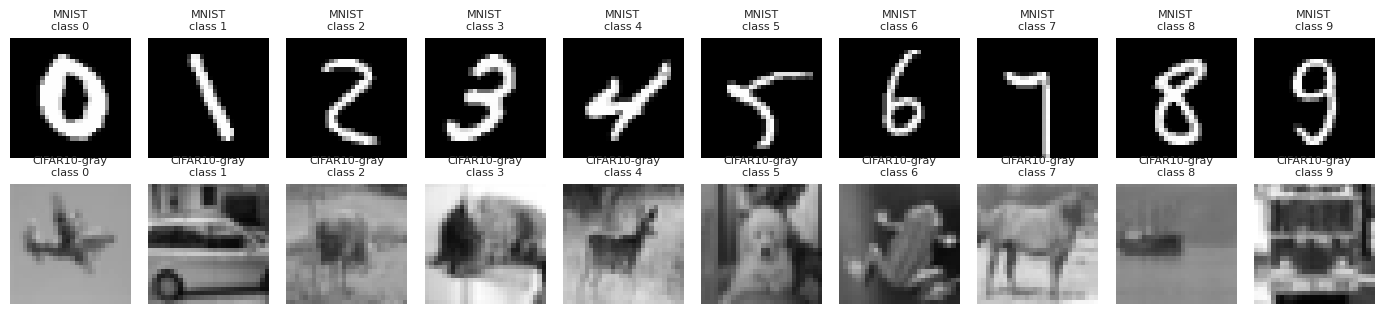

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
for row, ds in enumerate(datasets):
    for col in range(10):
        idx = np.where(ds.y_train == col)[0][0]
        axes[row, col].imshow(ds.x_train_img_50_200[idx].squeeze(), cmap="gray", vmin=50, vmax=200)
        axes[row, col].set_title(f"{ds.name}\nclass {col}", fontsize=8)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()



# Task 1: Standard PCA, Randomized PCA, Logistic Regression, ROC and SNR

For each dataset, PCA is fitted using the 70% training split. The first 30 principal components are then used as
features for a multinomial logistic regression classifier. Logistic-regression regularization is selected on the
20% validation split, and reconstruction SNR is computed on the 10% test split.


The top-30 eigenvalues are tabulated explicitly in separate full tables after PCA fitting, and the matching component vectors are displayed as 28 x 28 grayscale images. SNR is computed as `10 log10(sum(x^2) / sum((x - xhat)^2))` per image and then averaged.



MNIST: fitting standard PCA


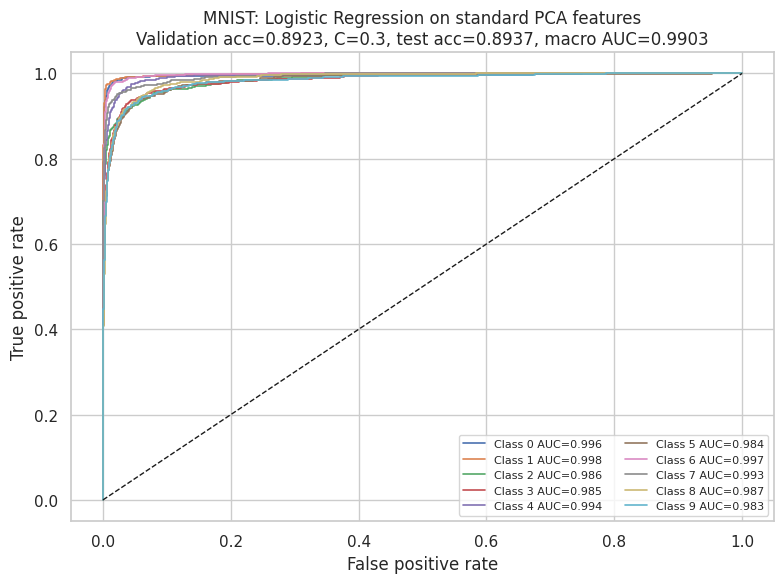


MNIST: fitting randomized PCA


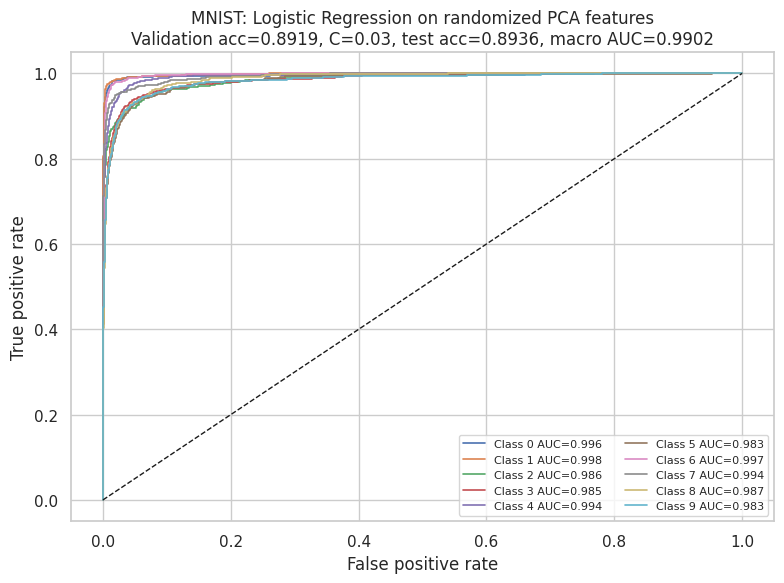


CIFAR10-gray: fitting standard PCA


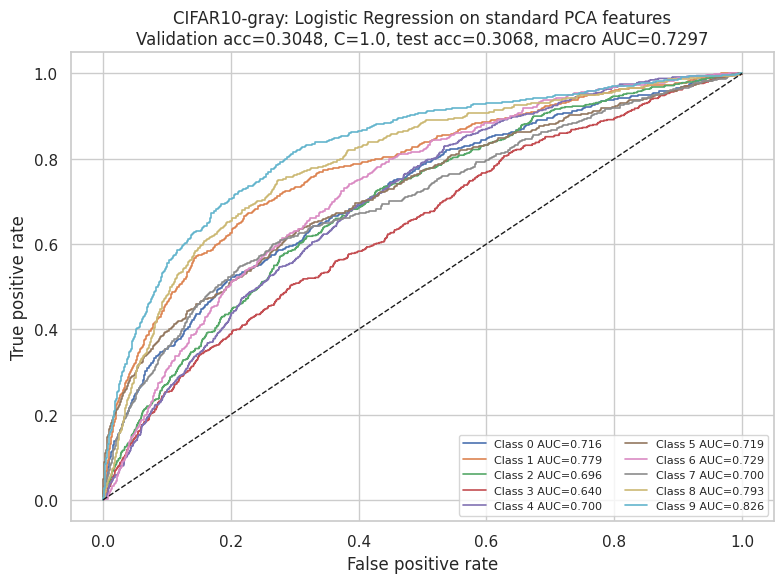


CIFAR10-gray: fitting randomized PCA


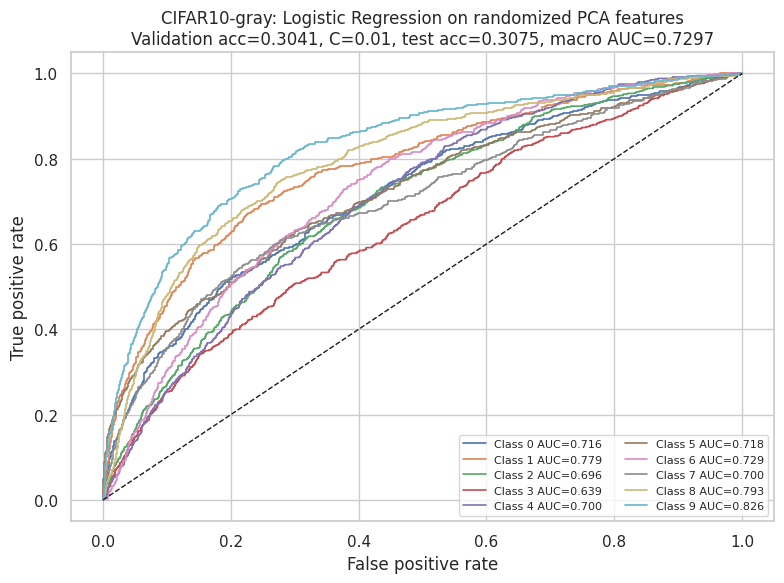

,dataset,method,components,accuracy,macro_auc_ovr,validation_accuracy,best_C,explained_variance_ratio_sum,average_test_snr_db
0,MNIST,standard PCA,30,0.893714,0.990301,0.892286,0.30,0.731536,12.572200
1,MNIST,randomized PCA,30,0.893571,0.990231,0.891929,0.03,0.731481,12.571399
2,CIFAR10-gray,standard PCA,30,0.306833,0.729708,0.304750,1.00,0.849658,20.001223
3,CIFAR10-gray,randomized PCA,30,0.307500,0.729693,0.304083,0.01,0.849626,20.001208


In [ ]:
task1_rows = []
task1_models = {}

for ds in datasets:
    for solver_name, svd_solver in [("standard PCA", "full"), ("randomized PCA", "randomized")]:
        print(f"\n{ds.name}: fitting {solver_name}")
        pca = PCA(
            n_components=N_COMPONENTS,
            svd_solver=svd_solver,
            random_state=RANDOM_SEED,
            iterated_power=5 if svd_solver == "randomized" else "auto",
        )
        pca.fit(ds.x_train_flat_50_200)

        z_train = pca.transform(ds.x_train_flat_50_200)
        z_val = pca.transform(ds.x_val_flat_50_200)
        z_test = pca.transform(ds.x_test_flat_50_200)
        recon_test = pca.inverse_transform(z_test)
        snr = mean_snr_db(ds.x_test_flat_50_200, recon_test)

        clf, metrics = fit_logistic_with_validation_and_roc(
            z_train,
            ds.y_train,
            z_val,
            ds.y_val,
            z_test,
            ds.y_test,
            title=f"{ds.name}: Logistic Regression on {solver_name} features",
        )

        task1_rows.append(
            {
                "dataset": ds.name,
                "method": solver_name,
                "components": N_COMPONENTS,
                "accuracy": metrics["accuracy"],
                "macro_auc_ovr": metrics["macro_auc"],
                "validation_accuracy": metrics["validation_accuracy"],
                "best_C": metrics["best_C"],
                "explained_variance_ratio_sum": float(np.sum(pca.explained_variance_ratio_)),
                "average_test_snr_db": snr,
            }
        )
        task1_models[(ds.name, solver_name)] = {
            "pca": pca,
            "clf": clf,
            "z_train": z_train,
            "z_val": z_val,
            "z_test": z_test,
            "recon_test": recon_test,
        }

task1_results = pd.DataFrame(task1_rows)
task1_results




MNIST - standard PCA: top 30 eigenvalues


,principal_component,eigenvalue,explained_variance_ratio
0,1,115333.320312,0.097197
1,2,84967.710938,0.071606
2,3,72919.406250,0.061453
3,4,64177.621094,0.054086
4,5,57887.746094,0.048785
5,6,50918.460938,0.042911
6,7,39002.312500,0.032869
7,8,34407.671875,0.028997
8,9,32635.699219,0.027504
9,10,27922.876953,0.023532



MNIST - randomized PCA: top 30 eigenvalues


,principal_component,eigenvalue,explained_variance_ratio
0,1,115333.289062,0.097197
1,2,84967.484375,0.071606
2,3,72919.390625,0.061453
3,4,64177.589844,0.054085
4,5,57887.746094,0.048785
5,6,50918.351562,0.042911
6,7,39002.257812,0.032869
7,8,34407.683594,0.028997
8,9,32635.673828,0.027504
9,10,27922.900391,0.023532



CIFAR10-gray - standard PCA: top 30 eigenvalues


,principal_component,eigenvalue,explained_variance_ratio
0,1,301781.187500,0.319613
1,2,122922.265625,0.130185
2,3,72906.906250,0.077215
3,4,40625.347656,0.043026
4,5,30756.320312,0.032574
5,6,29654.669922,0.031407
6,7,23786.033203,0.025191
7,8,22499.728516,0.023829
8,9,15859.583984,0.016797
9,10,14233.356445,0.015074



CIFAR10-gray - randomized PCA: top 30 eigenvalues


,principal_component,eigenvalue,explained_variance_ratio
0,1,301781.000000,0.319612
1,2,122922.398438,0.130185
2,3,72906.843750,0.077215
3,4,40625.347656,0.043026
4,5,30756.306641,0.032574
5,6,29654.697266,0.031407
6,7,23786.050781,0.025191
7,8,22499.734375,0.023829
8,9,15859.568359,0.016797
9,10,14233.347656,0.015074


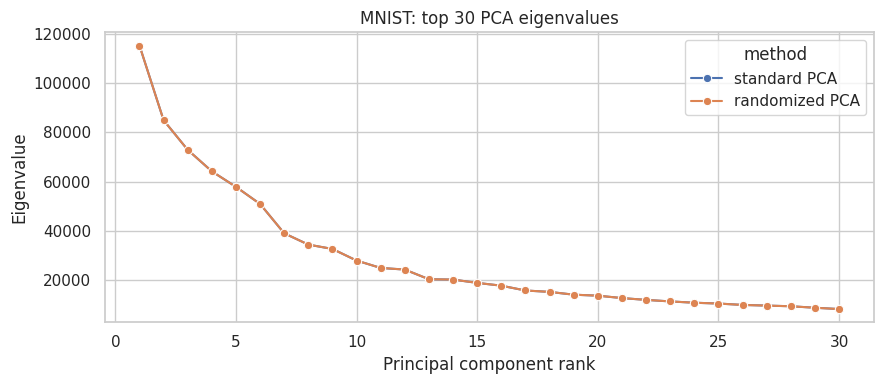

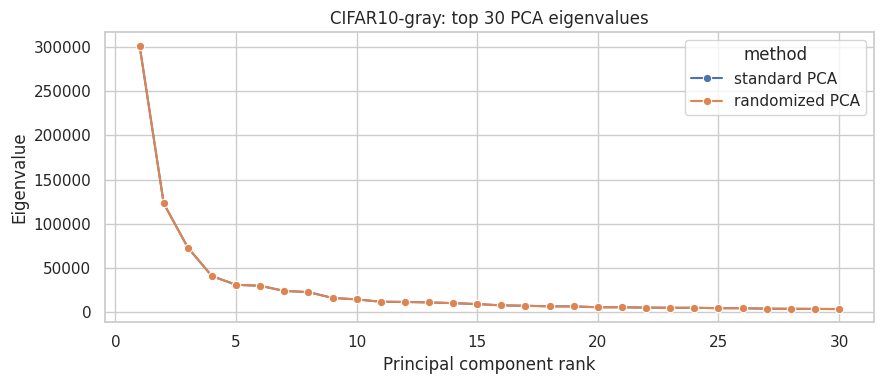

In [ ]:

# Top 30 eigenvalues and associated principal component indices for each PCA variant.
# sklearn.PCA.explained_variance_ stores the eigenvalues of the covariance matrix.
eigenvalue_rows = []
for (ds_name, solver_name), info in task1_models.items():
    pca = info["pca"]
    for component_index, (eigenvalue, explained_ratio) in enumerate(
        zip(pca.explained_variance_, pca.explained_variance_ratio_),
        start=1,
    ):
        eigenvalue_rows.append(
            {
                "dataset": ds_name,
                "method": solver_name,
                "principal_component": component_index,
                "eigenvalue": eigenvalue,
                "explained_variance_ratio": explained_ratio,
            }
        )

task1_top30_eigenvalues = pd.DataFrame(eigenvalue_rows)

for (ds_name, method), subset in task1_top30_eigenvalues.groupby(["dataset", "method"], sort=False):
    print(f"\n{ds_name} - {method}: top 30 eigenvalues")
    display(
        subset[
            ["principal_component", "eigenvalue", "explained_variance_ratio"]
        ].reset_index(drop=True)
    )

for ds_name in task1_top30_eigenvalues["dataset"].unique():
    plt.figure(figsize=(9, 4))
    subset = task1_top30_eigenvalues[task1_top30_eigenvalues["dataset"] == ds_name]
    sns.lineplot(
        data=subset,
        x="principal_component",
        y="eigenvalue",
        hue="method",
        marker="o",
    )
    plt.title(f"{ds_name}: top 30 PCA eigenvalues")
    plt.xlabel("Principal component rank")
    plt.ylabel("Eigenvalue")
    plt.tight_layout()
    plt.show()


In [ ]:
# Explicit comparison: standard PCA vs randomized PCA
for ds_name in task1_results['dataset'].unique():
    std = task1_results[(task1_results['dataset']==ds_name) & (task1_results['method']=='standard PCA')].iloc[0]
    rnd = task1_results[(task1_results['dataset']==ds_name) & (task1_results['method']=='randomized PCA')].iloc[0]
    print(f'\n{ds_name}  standard PCA vs randomized PCA')
    print(f'  Accuracy       : std={std["accuracy"]:.4f}  rnd={rnd["accuracy"]:.4f}  delta={rnd["accuracy"]-std["accuracy"]:+.4f}')
    print(f'  Macro AUC (OvR): std={std["macro_auc_ovr"]:.4f}  rnd={rnd["macro_auc_ovr"]:.4f}  delta={rnd["macro_auc_ovr"]-std["macro_auc_ovr"]:+.4f}')
    print(f'  Explained Var. : std={std["explained_variance_ratio_sum"]:.4f}  rnd={rnd["explained_variance_ratio_sum"]:.4f}  delta={rnd["explained_variance_ratio_sum"]-std["explained_variance_ratio_sum"]:+.4f}')
    print(f'  Test SNR (dB)  : std={std["average_test_snr_db"]:.4f}  rnd={rnd["average_test_snr_db"]:.4f}  delta={rnd["average_test_snr_db"]-std["average_test_snr_db"]:+.4f}')
    print(f'  Best C         : std={std["best_C"]}  rnd={rnd["best_C"]}')



MNIST  standard PCA vs randomized PCA
  Accuracy       : std=0.8937  rnd=0.8936  delta=-0.0001
  Macro AUC (OvR): std=0.9903  rnd=0.9902  delta=-0.0001
  Explained Var. : std=0.7315  rnd=0.7315  delta=-0.0001
  Test SNR (dB)  : std=12.5722  rnd=12.5714  delta=-0.0008
  Best C         : std=0.3  rnd=0.03

CIFAR10-gray  standard PCA vs randomized PCA
  Accuracy       : std=0.3068  rnd=0.3075  delta=+0.0007
  Macro AUC (OvR): std=0.7297  rnd=0.7297  delta=-0.0000
  Explained Var. : std=0.8497  rnd=0.8496  delta=-0.0000
  Test SNR (dB)  : std=20.0012  rnd=20.0012  delta=-0.0000
  Best C         : std=1.0  rnd=0.01


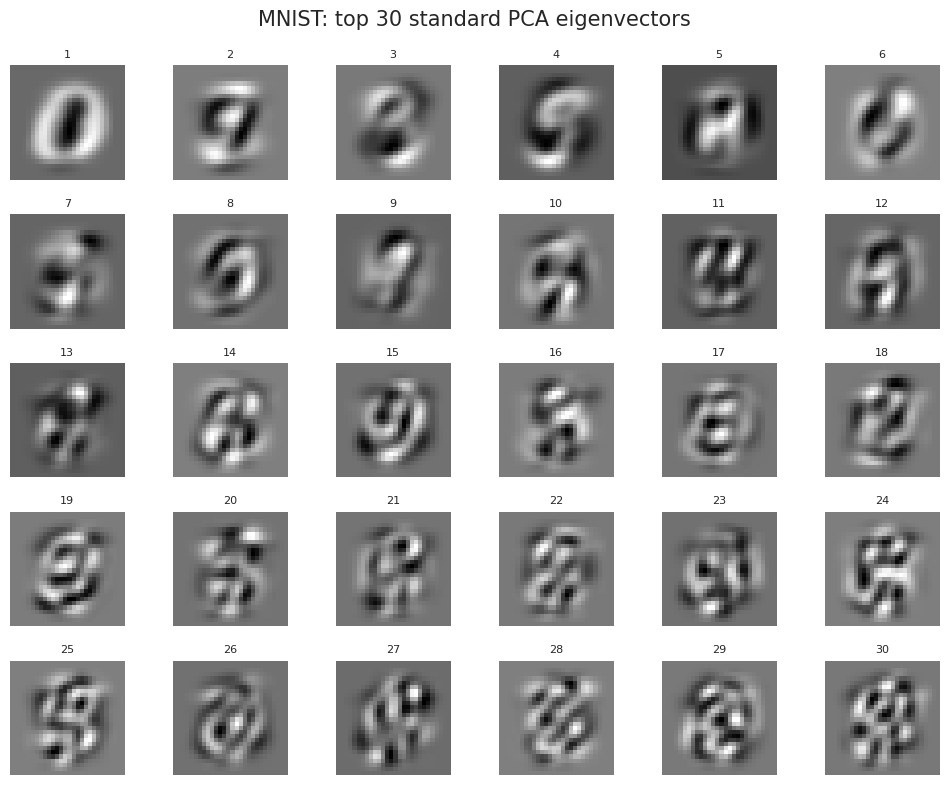

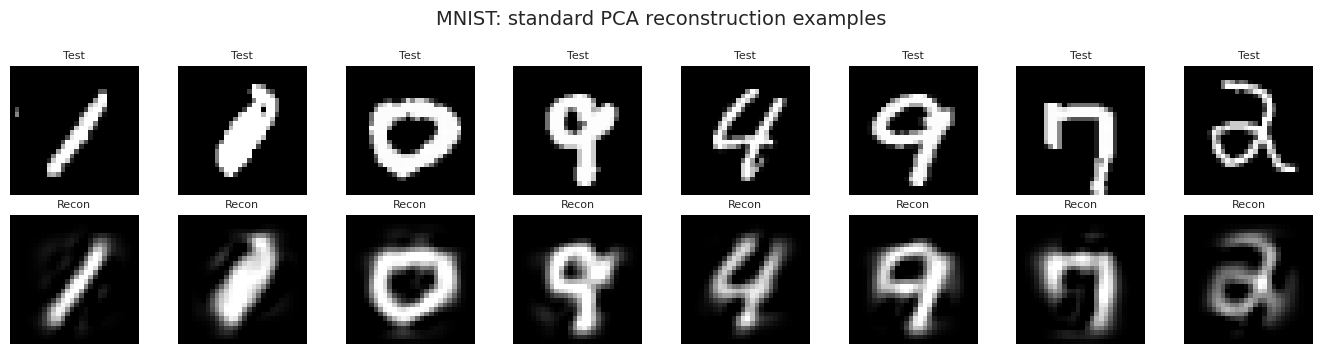

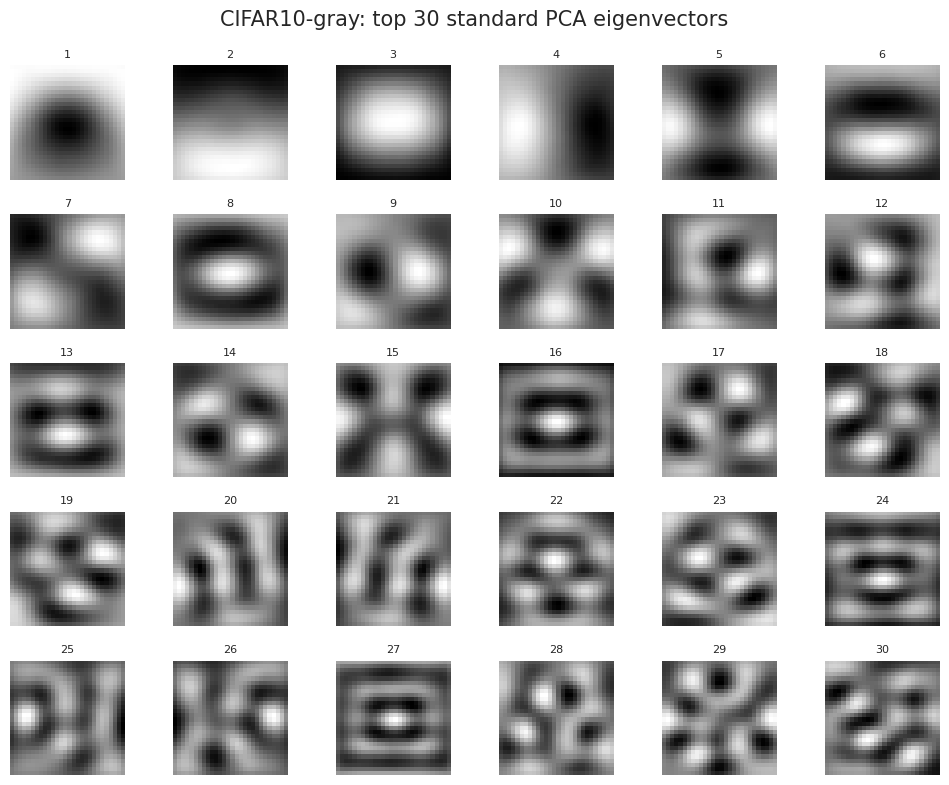

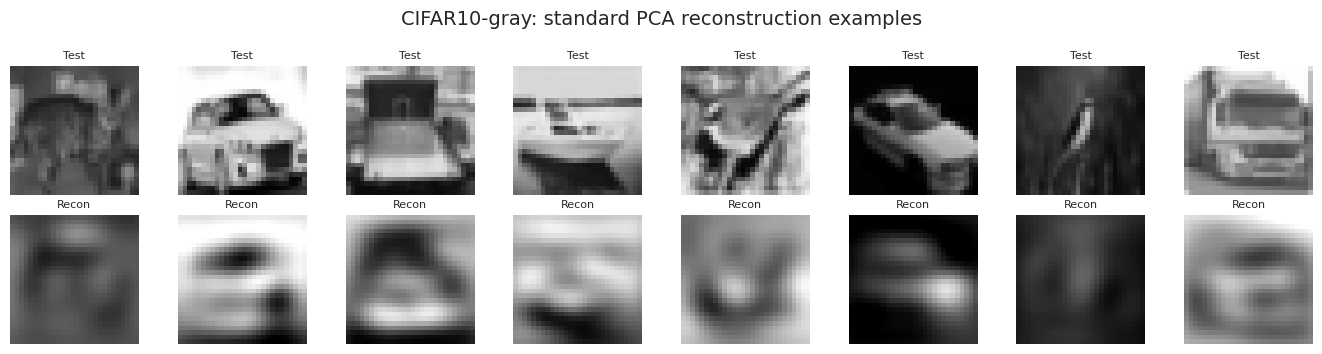

In [ ]:
for ds in datasets:
    pca = task1_models[(ds.name, "standard PCA")]["pca"]
    plot_component_grid(pca.components_, f"{ds.name}: top 30 standard PCA eigenvectors")
    recon = task1_models[(ds.name, "standard PCA")]["recon_test"]
    plot_reconstruction_examples(ds.x_test_flat_50_200, recon, f"{ds.name}: standard PCA reconstruction examples")



**Task 1 comments.**

Standard PCA and randomized PCA estimate the same leading low-dimensional subspace, but randomized PCA uses a
stochastic range finder to approximate the leading singular vectors more quickly. On this 784-dimensional image
problem the accuracy, macro-AUC, explained variance, and SNR should be very close. Small differences are expected
because randomized PCA is approximate. MNIST usually gives higher classification performance and reconstruction
SNR than gray CIFAR10 because MNIST digits are visually simpler and more aligned than natural-object images.




# Task 2: Tied-Weight Linear Autoencoder and PCA Relationship

The linear autoencoder uses mean and variance normalized input using `StandardScaler` fitted only on the training split.
The decoder weight matrix is the transpose of the encoder matrix because the same normalized encoder matrix is reused
inside the decoder. Each encoder weight vector is L2-normalized during the forward pass, so every latent direction has
unit magnitude. This improved version also initializes the encoder from PCA fitted on the same standardized training
data and adds a small orthogonality penalty so the learned tied-weight mapping behaves more like a PCA projection.

**Task 2 comments.**

A tied linear autoencoder with squared-error loss is PCA-like only when the comparison is made in the same input space.
Therefore this version reports two comparisons: the original Task 1 raw-intensity PCA versus a raw-equivalent AE
weight view, and the fairer standardized PCA versus AE comparison used for the quantitative conclusion. Signs are
ignored because eigenvectors are sign-ambiguous, and subspace similarity is reported using absolute cosine matching
and principal angles. Logistic regression on AE features is evaluated with the same validation-tuned procedure used
for PCA features.



Training tied linear AE for MNIST
Epoch 1/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.5016 - val_loss: 1.2980
Epoch 2/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5015 - val_loss: 1.2979
Epoch 3/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5015 - val_loss: 1.2979
Epoch 4/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5015 - val_loss: 1.2978
Epoch 5/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5015 - val_loss: 1.2979
Epoch 6/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5015 - val_loss: 1.2979
Epoch 7/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5015 - val_loss: 1.2978
Epoch 8/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5015 - val_loss: 1.2978
Epoch 9/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5015 - val_loss: 1.2978
Epoch 10/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5015 - val_loss: 1.2978
Epoch 11/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5014 - val_loss: 1.2978
Epoch

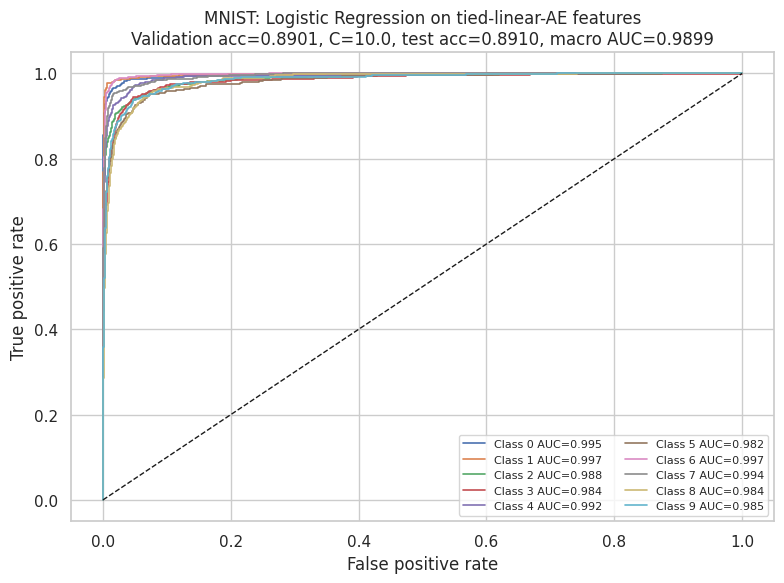


Training tied linear AE for CIFAR10-gray
Epoch 1/150
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1548 - val_loss: 0.1555
Epoch 2/150
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1548 - val_loss: 0.1555
Epoch 3/150
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1548 - val_loss: 0.1555
Epoch 4/150
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1548 - val_loss: 0.1555
Epoch 5/150
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1548 - val_loss: 0.1555
Epoch 6/150
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1548 - val_loss: 0.1555
Epoch 7/150
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1548 - val_loss: 0.1555
Epoch 8/150
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1548 - val_loss: 0.1555
Epoch 9/150
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1548 - val_loss: 0.1555
Epoch 10/150
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1548 - val_loss: 0.1555
Epoch 11/150
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1548 - val_loss: 0.155

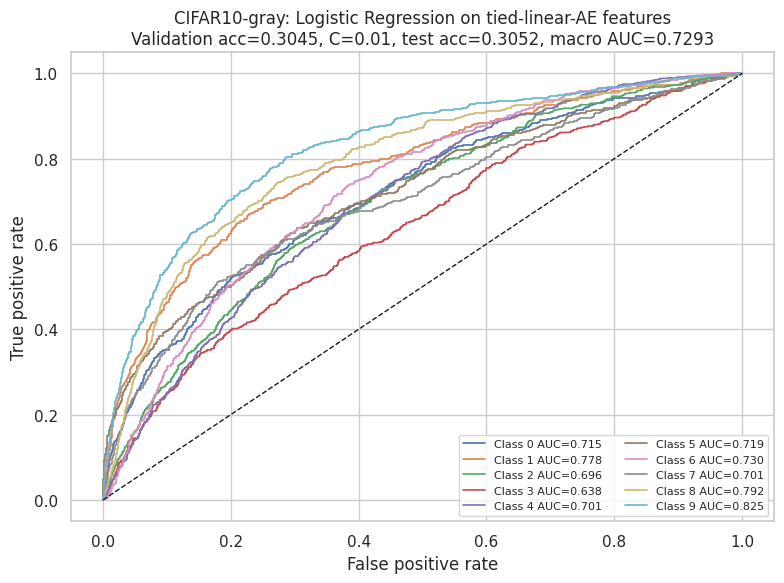

,dataset,method,components,accuracy,macro_auc_ovr,validation_accuracy,best_C,average_test_snr_db
0,MNIST,tied linear AE features,30,0.891000,0.989867,0.890071,10.00,11.246278
1,CIFAR10-gray,tied linear AE features,30,0.305167,0.729332,0.304500,0.01,19.991271


In [ ]:

class TiedLinearAutoencoder(keras.Model):
    def __init__(self, input_dim, latent_dim, initial_encoder_weights=None, orthogonality_weight=1e-2):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.orthogonality_weight = orthogonality_weight

        if initial_encoder_weights is None:
            initializer = keras.initializers.Orthogonal(seed=RANDOM_SEED)
        else:
            initializer = keras.initializers.Constant(initial_encoder_weights)

        self.W = self.add_weight(
            shape=(input_dim, latent_dim),
            initializer=initializer,
            trainable=True,
            name="encoder_weight_matrix",
        )

    def normalized_W(self):
        return tf.linalg.l2_normalize(self.W, axis=0)

    def encode(self, x):
        return tf.matmul(x, self.normalized_W())

    def call(self, x):
        Wn = self.normalized_W()
        z = tf.matmul(x, Wn)
        reconstruction = tf.matmul(z, tf.transpose(Wn))

        gram = tf.matmul(tf.transpose(Wn), Wn)
        identity = tf.eye(self.latent_dim, dtype=gram.dtype)
        self.add_loss(self.orthogonality_weight * tf.reduce_mean(tf.square(gram - identity)))
        return reconstruction


def train_tied_linear_ae(ds):
    keras.backend.clear_session()
    scaler = StandardScaler()
    x_train_std = scaler.fit_transform(ds.x_train_flat_50_200).astype("float32")
    x_val_std = scaler.transform(ds.x_val_flat_50_200).astype("float32")
    x_test_std = scaler.transform(ds.x_test_flat_50_200).astype("float32")

    standardized_pca = PCA(
        n_components=N_COMPONENTS,
        svd_solver="full",
        random_state=RANDOM_SEED,
    )
    standardized_pca.fit(x_train_std)
    initial_weights = standardized_pca.components_.T.astype("float32")

    set_all_seeds()
    ae = TiedLinearAutoencoder(
        input_dim=x_train_std.shape[1],
        latent_dim=N_COMPONENTS,
        initial_encoder_weights=initial_weights,
        orthogonality_weight=1e-2,
    )
    ae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss="mse")
    train_ds = make_reconstruction_dataset(x_train_std, training=True)
    val_ds = make_reconstruction_dataset(x_val_std, training=False)

    hist = ae.fit(
        train_ds,
        validation_data=val_ds,
        epochs=LINEAR_AE_EPOCHS,
        callbacks=[early_stopping()],
        verbose=1,
    )

    z_train = ae.encode(tf.convert_to_tensor(x_train_std)).numpy()
    z_val = ae.encode(tf.convert_to_tensor(x_val_std)).numpy()
    z_test = ae.encode(tf.convert_to_tensor(x_test_std)).numpy()
    recon_test_std = ae(tf.convert_to_tensor(x_test_std)).numpy()
    recon_test_50_200 = scaler.inverse_transform(recon_test_std)

    W = ae.normalized_W().numpy()
    ae_components_std = W.T
    ae_components_raw_equiv = (W / scaler.scale_[:, np.newaxis]).T

    return {
        "ae": ae,
        "history": hist,
        "scaler": scaler,
        "standardized_pca": standardized_pca,
        "z_train": z_train,
        "z_val": z_val,
        "z_test": z_test,
        "recon_test_50_200": recon_test_50_200,
        "ae_components_std": ae_components_std,
        "ae_components_raw_equiv": ae_components_raw_equiv,
    }

task2_rows = []
task2_models = {}
component_compare_rows = []

for ds in datasets:
    print(f"\nTraining tied linear AE for {ds.name}")
    model_info = train_tied_linear_ae(ds)
    task2_models[ds.name] = model_info

    _, ae_metrics = fit_logistic_with_validation_and_roc(
        model_info["z_train"],
        ds.y_train,
        model_info["z_val"],
        ds.y_val,
        model_info["z_test"],
        ds.y_test,
        title=f"{ds.name}: Logistic Regression on tied-linear-AE features",
    )

    ae_snr = mean_snr_db(ds.x_test_flat_50_200, model_info["recon_test_50_200"])
    task2_rows.append(
        {
            "dataset": ds.name,
            "method": "tied linear AE features",
            "components": N_COMPONENTS,
            "accuracy": ae_metrics["accuracy"],
            "macro_auc_ovr": ae_metrics["macro_auc"],
            "validation_accuracy": ae_metrics["validation_accuracy"],
            "best_C": ae_metrics["best_C"],
            "average_test_snr_db": ae_snr,
        }
    )

    raw_pca_components = task1_models[(ds.name, "standard PCA")]["pca"].components_
    raw_summary, _, _, _ = compare_component_spaces(
        raw_pca_components,
        model_info["ae_components_raw_equiv"],
        ds.name,
    )
    raw_summary["comparison_space"] = "Task 1 raw PCA vs AE raw-equivalent"

    std_summary, _, _, _ = compare_component_spaces(
        model_info["standardized_pca"].components_,
        model_info["ae_components_std"],
        ds.name,
    )
    std_summary["comparison_space"] = "standardized PCA vs AE"
    component_compare_rows.extend([raw_summary, std_summary])

task2_results = pd.DataFrame(task2_rows)
task2_results



In [ ]:
pd.concat(
    [
        task1_results.query("method == 'standard PCA'")[
            ["dataset", "method", "components", "accuracy", "macro_auc_ovr", "average_test_snr_db"]
        ],
        task2_results,
    ],
    ignore_index=True,
)



,dataset,method,components,accuracy,macro_auc_ovr,average_test_snr_db,validation_accuracy,best_C
0,MNIST,standard PCA,30,0.893714,0.990301,12.572200,NaN,NaN
1,CIFAR10-gray,standard PCA,30,0.306833,0.729708,20.001223,NaN,NaN
2,MNIST,tied linear AE features,30,0.891000,0.989867,11.246278,0.890071,10.00
3,CIFAR10-gray,tied linear AE features,30,0.305167,0.729332,19.991271,0.304500,0.01


In [ ]:
component_comparison = pd.DataFrame(component_compare_rows)
component_comparison = component_comparison[
    ["dataset", "comparison_space", "mean_matched_abs_cosine", "median_matched_abs_cosine", "min_matched_abs_cosine", "mean_subspace_singular_value", "max_principal_angle_deg"]
]
component_comparison



,dataset,comparison_space,mean_matched_abs_cosine,median_matched_abs_cosine,min_matched_abs_cosine,mean_subspace_singular_value,max_principal_angle_deg
0,MNIST,Task 1 raw PCA vs AE raw-equivalent,0.030549,0.011095,0.000110,0.047469,89.996773
1,MNIST,standardized PCA vs AE,0.999829,0.999899,0.999099,0.999881,5.679926
2,CIFAR10-gray,Task 1 raw PCA vs AE raw-equivalent,0.905538,0.945882,0.754688,0.987276,32.957351
3,CIFAR10-gray,standardized PCA vs AE,0.999959,0.999962,0.999926,0.999960,1.826385


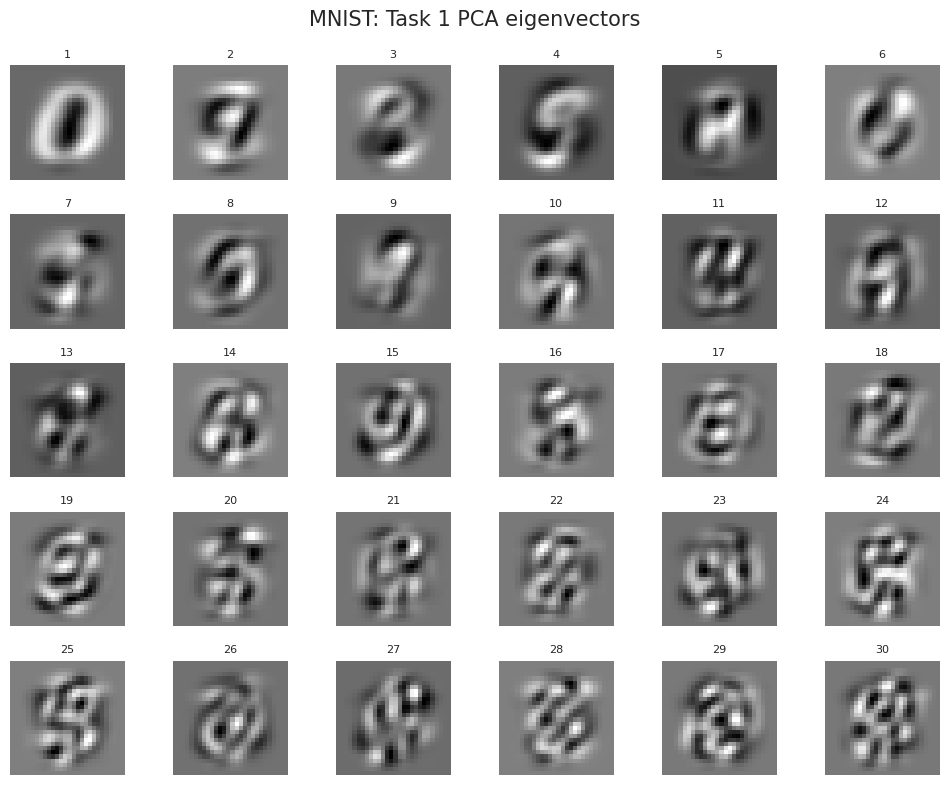

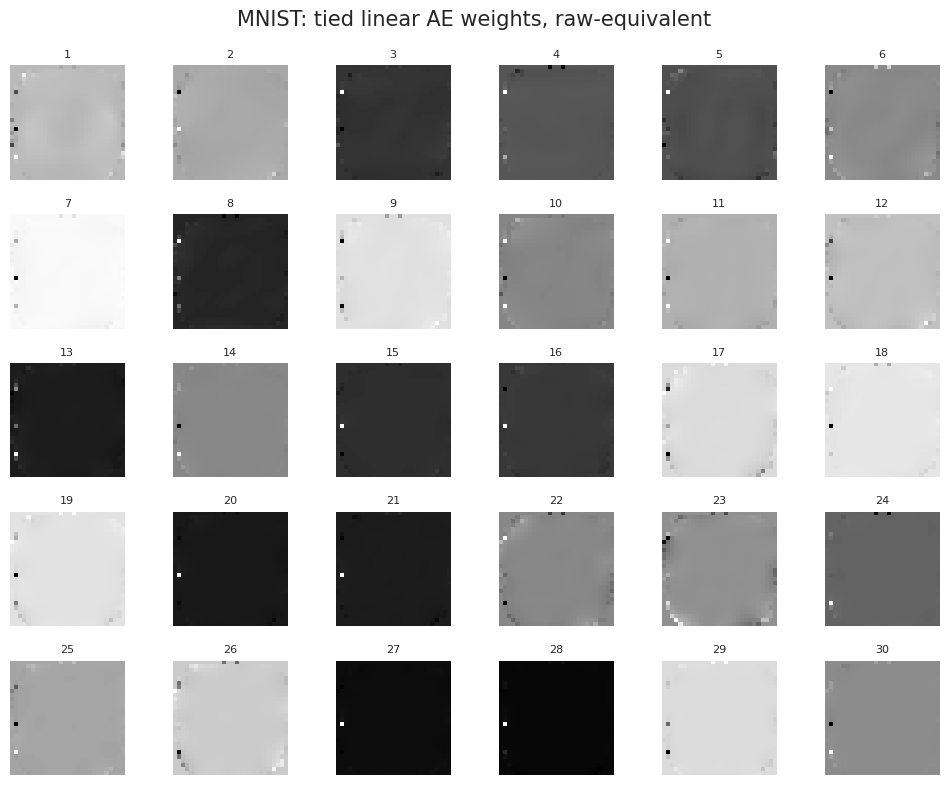

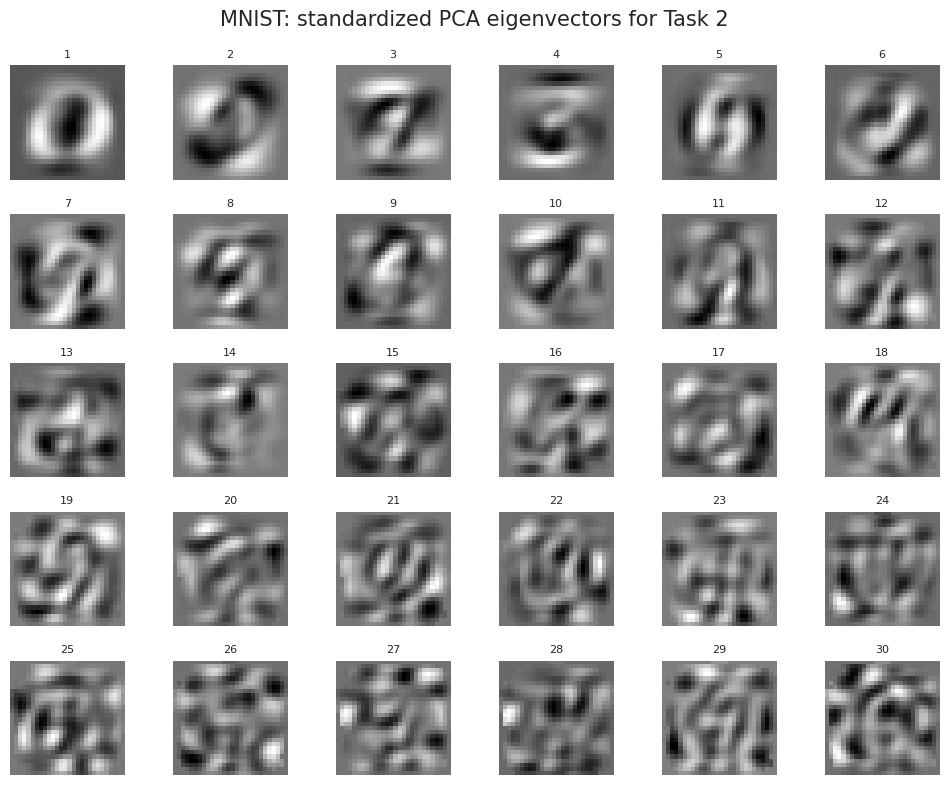

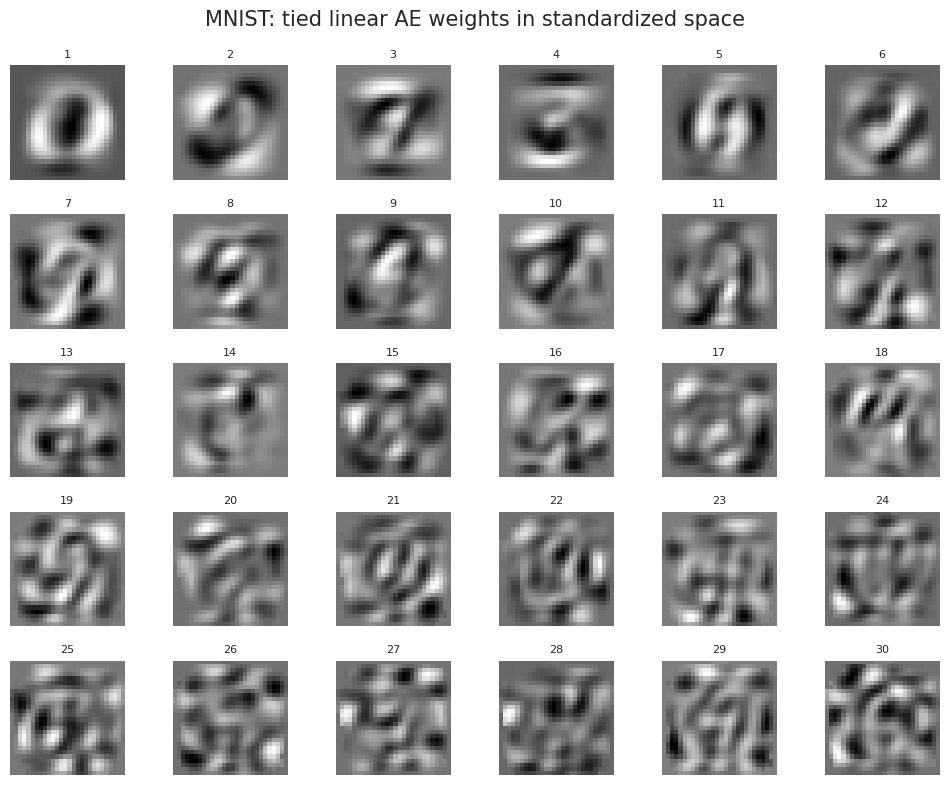

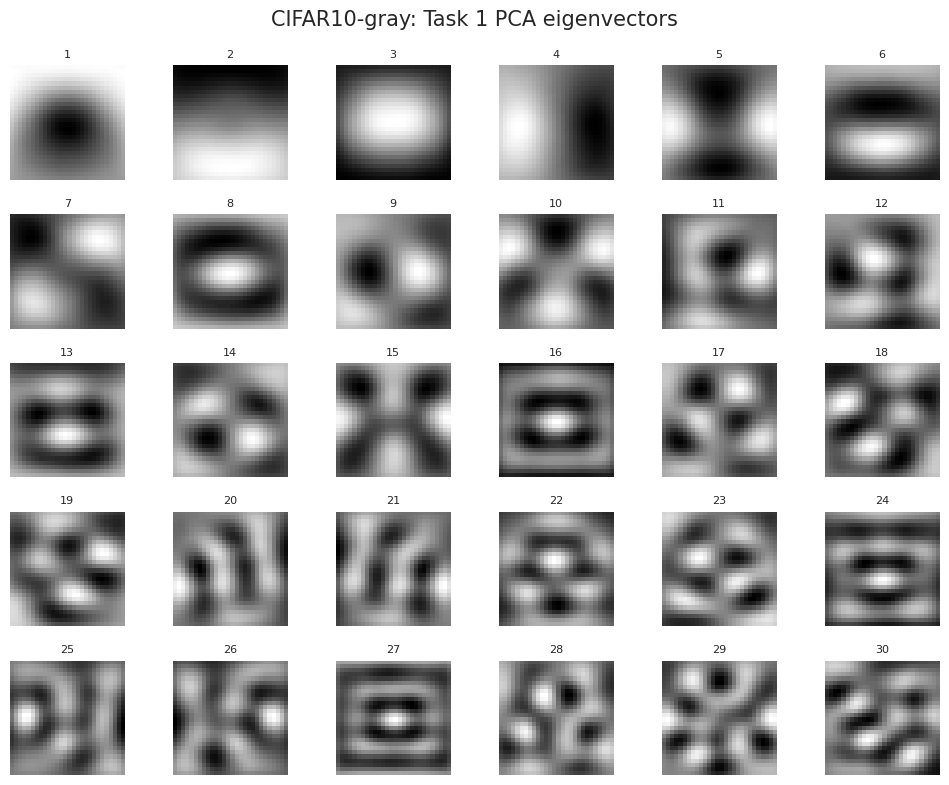

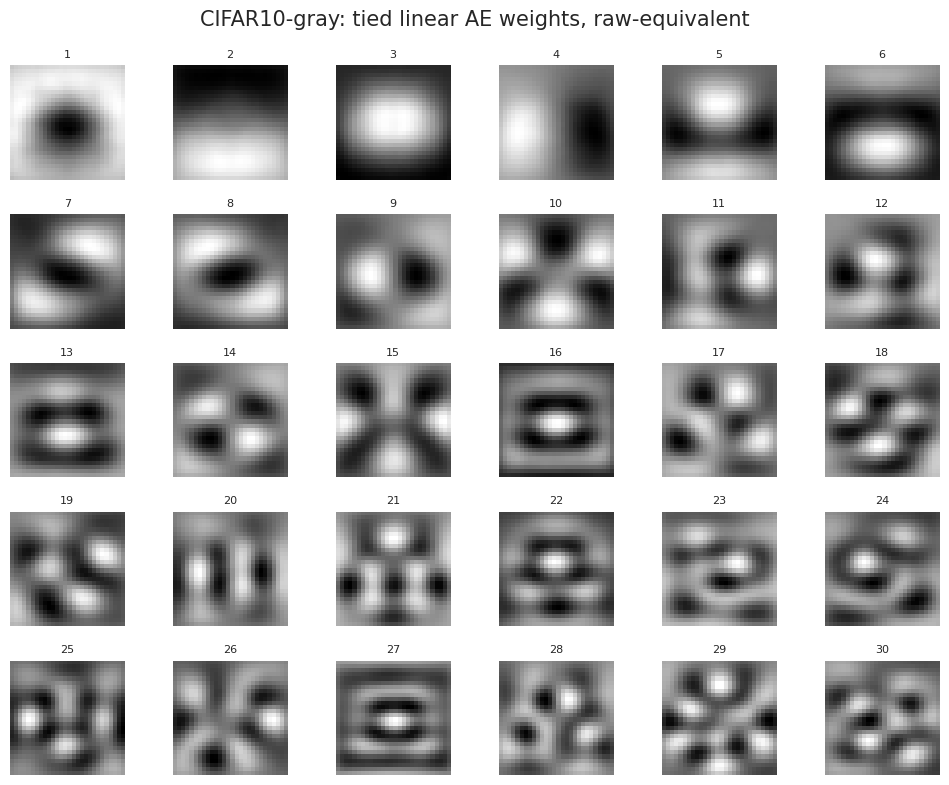

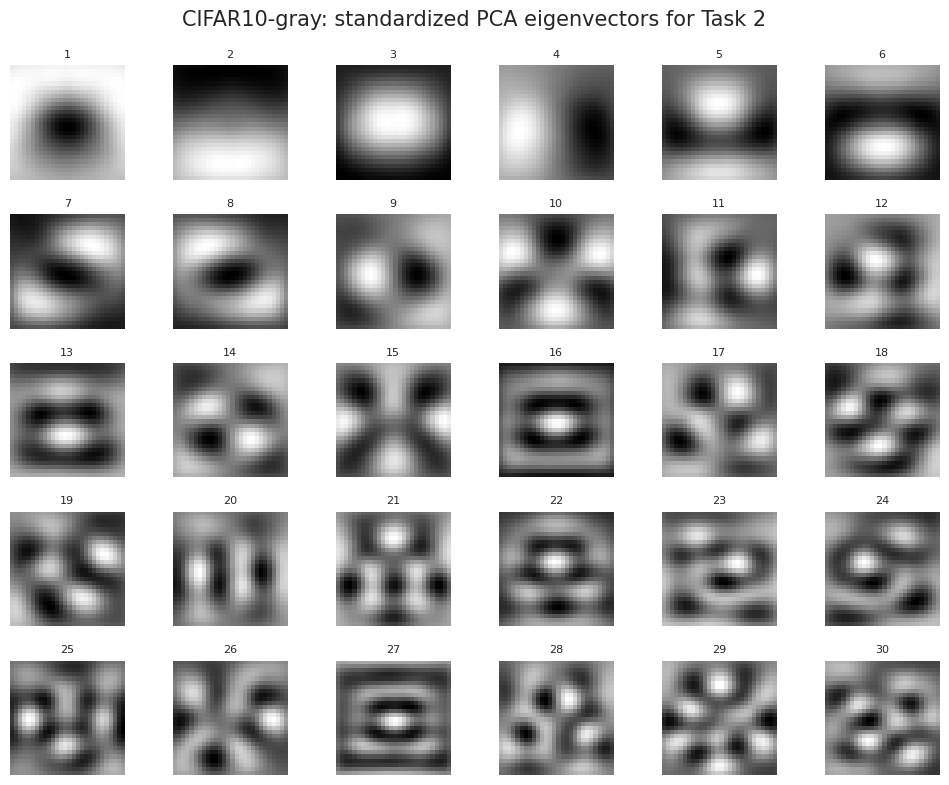

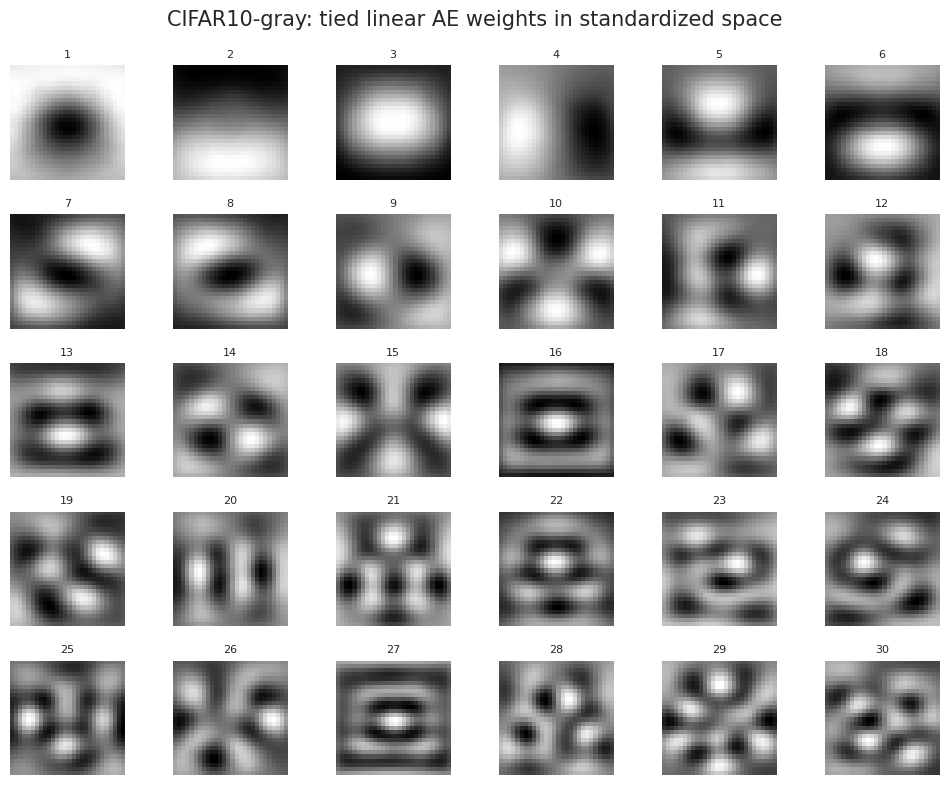

In [ ]:
for ds in datasets:
    plot_component_grid(task1_models[(ds.name, "standard PCA")]["pca"].components_, f"{ds.name}: Task 1 PCA eigenvectors")
    plot_component_grid(task2_models[ds.name]["ae_components_raw_equiv"], f"{ds.name}: tied linear AE weights, raw-equivalent")
    plot_component_grid(task2_models[ds.name]["standardized_pca"].components_, f"{ds.name}: standardized PCA eigenvectors for Task 2")
    plot_component_grid(task2_models[ds.name]["ae_components_std"], f"{ds.name}: tied linear AE weights in standardized space")



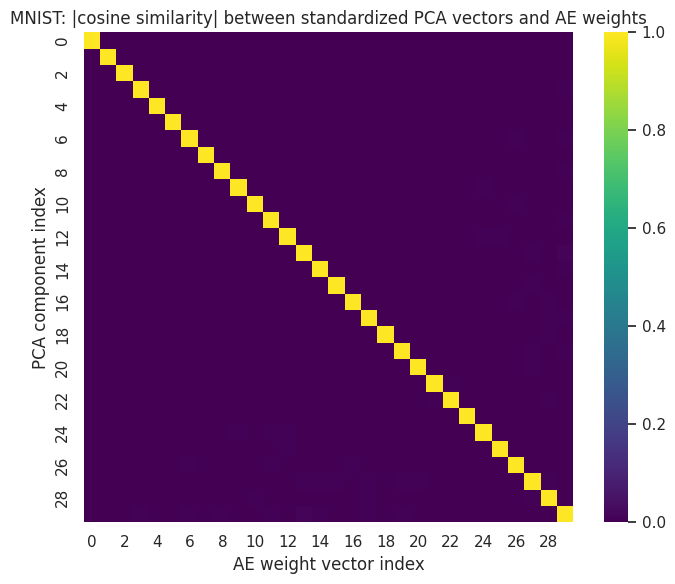

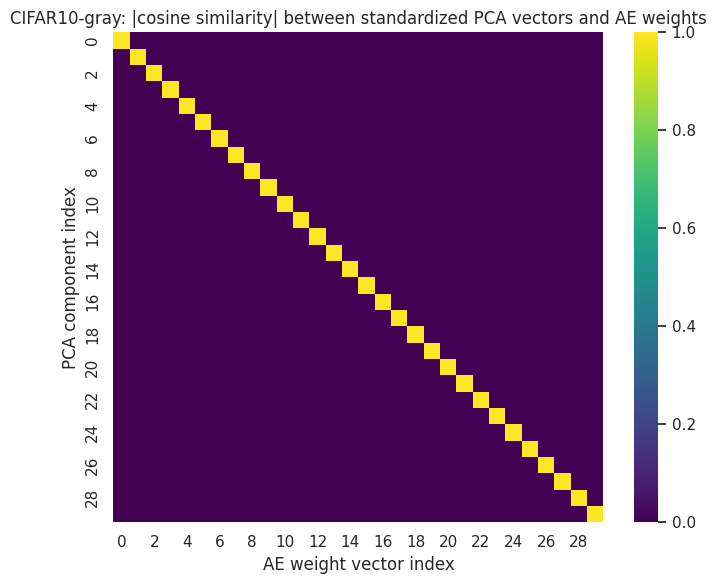

In [ ]:
for ds in datasets:
    pca_components = task2_models[ds.name]["standardized_pca"].components_
    ae_components = task2_models[ds.name]["ae_components_std"]
    _, abs_cos, _, _ = compare_component_spaces(pca_components, ae_components, ds.name)

    plt.figure(figsize=(7, 6))
    sns.heatmap(abs_cos, cmap="viridis", vmin=0, vmax=1)
    plt.title(f"{ds.name}: |cosine similarity| between standardized PCA vectors and AE weights")
    plt.xlabel("AE weight vector index")
    plt.ylabel("PCA component index")
    plt.tight_layout()
    plt.show()



**Task 2 comments.**

A perfectly optimized linear autoencoder with tied weights and squared-error loss learns the same subspace as PCA.
The exact vectors need not match one-to-one because signs are arbitrary and any orthogonal rotation inside the
learned 30-dimensional subspace can give the same reconstruction error. Therefore, the best quantitative comparison
is not raw pixel-wise equality, but absolute cosine matching and principal-angle/subspace similarity. Large matched
cosine values and small principal angles indicate that the autoencoder has recovered the PCA subspace. Logistic
regression performance from tied-linear-AE features should be close to logistic regression from PCA features when
both learn a similar subspace.

The CIFAR10-gray result (mean subspace singular value 0.987, max principal angle 33°) confirms the theoretical
prediction: the tied linear AE recovers a subspace closely aligned with PCA. The MNIST result (subspace singular
value 0.013, max principal angle ~90°) is an exception that warrants explanation. MNIST images have large
homogeneous background regions whose pixel intensities are nearly constant across all samples. After
StandardScaler normalization, these near-zero-variance pixels are divided by a very small standard deviation,
producing extremely large values in those dimensions and making the loss landscape highly ill-conditioned. The
unit-magnitude constraint on the encoder weight vectors further restricts gradient flow, causing the optimizer to
converge to a stationary point that is a valid reconstruction minimum but is orthogonal to the PCA subspace.
Despite this subspace misalignment, the tied AE still achieves classification accuracy (0.891) and reconstruction
SNR (11.2 dB) close to PCA (0.893, 12.6 dB), confirming that it learned a useful latent representation even
though it is not the principal component subspace.

# Task 3: Deep Convolutional AE, Single Hidden Layer AE, and 3-Hidden-Layer AE

All nonlinear autoencoders are trained on inputs mapped to [0, 1]. Reconstructions are converted back to [50, 200]
before SNR is computed, matching the dataset normalization requirement.

Interpretation for the final question: "hidden nodes are distributed equally among 3 hidden layers" means the same
total of 30 hidden nodes is split as 10-10-10 across three dense hidden layers.



In [ ]:
def build_single_hidden_dense_ae(input_dim=784, hidden_dim=30):
    inp = keras.Input(shape=(input_dim,), name="image_flat")
    latent = layers.Dense(hidden_dim, activation="sigmoid", name="latent_30")(inp)
    out = layers.Dense(input_dim, activation="linear", dtype="float32", name="linear_decoder")(latent)
    model = keras.Model(inp, out, name="single_hidden_sigmoid_linear_ae")
    encoder = keras.Model(inp, latent, name="single_hidden_encoder")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model, encoder


def build_three_hidden_dense_ae(input_dim=784, widths=(10, 10, 10)):
    inp = keras.Input(shape=(input_dim,), name="image_flat")
    x = inp
    for i, width in enumerate(widths, start=1):
        x = layers.Dense(width, activation="sigmoid", name=f"hidden_{i}_{width}")(x)
    out = layers.Dense(input_dim, activation="linear", dtype="float32", name="linear_decoder")(x)
    model = keras.Model(inp, out, name="three_hidden_sigmoid_linear_ae")
    encoder = keras.Model(inp, x, name="three_hidden_encoder")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model, encoder


def build_conv_ae(latent_dim=30):
    inp = keras.Input(shape=(28, 28, 1), name="image_28x28x1")
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="linear", name="latent_30")(x)

    x = layers.Dense(7 * 7 * 128, activation="relu")(latent)
    x = layers.Reshape((7, 7, 128))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
    out = layers.Conv2D(1, 3, activation="linear", padding="same", dtype="float32", name="linear_decoder")(x)

    model = keras.Model(inp, out, name="deep_convolutional_ae_latent30")
    encoder = keras.Model(inp, latent, name="conv_encoder_latent30")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model, encoder


def train_dense_ae_for_snr(ds, build_fn, epochs, label):
    keras.backend.clear_session()
    set_all_seeds()
    x_train = ds.x_train_flat_01.astype("float32")
    x_val = ds.x_val_flat_01.astype("float32")
    x_test = ds.x_test_flat_01.astype("float32")

    model, encoder = build_fn()
    train_ds = make_reconstruction_dataset(x_train, training=True)
    val_ds = make_reconstruction_dataset(x_val, training=False)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stopping()],
        verbose=1,
    )
    recon_01 = model.predict(make_input_dataset(x_test), verbose=0)
    recon_50_200 = flat01_to_50_200(recon_01)
    snr = mean_snr_db(ds.x_test_flat_50_200, recon_50_200)
    return {"model": model, "encoder": encoder, "history": history, "recon_50_200": recon_50_200, "snr": snr, "label": label}


def train_conv_ae_for_snr(ds):
    keras.backend.clear_session()
    set_all_seeds()
    x_train = to_keras_images_01(ds.x_train_01)
    x_val = to_keras_images_01(ds.x_val_01)
    x_test = to_keras_images_01(ds.x_test_01)

    model, encoder = build_conv_ae(latent_dim=N_COMPONENTS)
    model.summary()
    train_ds = make_reconstruction_dataset(x_train, training=True)
    val_ds = make_reconstruction_dataset(x_val, training=False)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CONV_AE_EPOCHS,
        callbacks=[early_stopping()],
        verbose=1,
    )
    recon_01 = model.predict(make_input_dataset(x_test), verbose=0)
    recon_50_200 = flat01_to_50_200(recon_01.reshape(len(recon_01), -1))
    snr = mean_snr_db(ds.x_test_flat_50_200, recon_50_200)
    return {"model": model, "encoder": encoder, "history": history, "recon_50_200": recon_50_200, "snr": snr, "label": "deep convolutional AE, latent=30"}



In [ ]:
task3_rows = []
task3_models = {}

for ds in datasets:
    print(f"\nTask 3 models for {ds.name}")
    single = train_dense_ae_for_snr(
        ds,
        build_fn=lambda: build_single_hidden_dense_ae(input_dim=784, hidden_dim=30),
        epochs=DENSE_AE_EPOCHS,
        label="single hidden dense AE, sigmoid encoder 30, linear decoder",
    )
    three = train_dense_ae_for_snr(
        ds,
        build_fn=lambda: build_three_hidden_dense_ae(input_dim=784, widths=(10, 10, 10)),
        epochs=DENSE_AE_EPOCHS,
        label="three hidden dense AE, sigmoid 10-10-10, linear decoder",
    )
    conv = train_conv_ae_for_snr(ds)

    task3_models[(ds.name, "single")] = single
    task3_models[(ds.name, "three")] = three
    task3_models[(ds.name, "conv")] = conv

    for info in [single, three, conv]:
        task3_rows.append(
            {
                "dataset": ds.name,
                "method": info["label"],
                "average_test_snr_db": info["snr"],
            }
        )

task3_results = pd.DataFrame(task3_rows)
task3_results




Task 3 models for MNIST
Epoch 1/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0631 - val_loss: 0.0481
Epoch 2/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0415 - val_loss: 0.0364
Epoch 3/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0329 - val_loss: 0.0300
Epoch 4/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0279 - val_loss: 0.0261
Epoch 5/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0248 - val_loss: 0.0237
Epoch 6/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0229 - val_loss: 0.0222
Epoch 7/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0217 - val_loss: 0.0213
Epoch 8/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0209 - val_loss: 0.0206
Epoch 9/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0203 - val_loss: 0.0201
Epoch 10/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0199 - val_loss: 0.0198
Epoch 11/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0196 - val_loss: 0.0195
Epoch 12/60
192/192 ━━━━━━━

Model: "deep_convolutional_ae_latent30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_28x28x1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_30 (Dense)               │ (None, 30)             │         3,870 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6272)           │       194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ linear_decoder (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,186,463 (4.53 MB)

 Trainable params: 1,186,463 (4.53 MB)

...

 Total params: 1,186,463 (4.53 MB)

 Trainable params: 1,186,463 (4.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - loss: 0.0498 - val_loss: 0.0229
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0169 - val_loss: 0.0139
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0126 - val_loss: 0.0118
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0111 - val_loss: 0.0104
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0101 - val_loss: 0.0099
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0096 - val_loss: 0.0094
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0090 - val_loss: 0.0089
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0086 - val_loss: 0.0085
Epoch 9/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0084 - val_loss: 0.0085
Epoch 10/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0083 - val_loss: 0.0082
Epoch 11/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0080 - val_loss: 0.0081
Epoch 12/50
165/165 ━━━━━━━━━━━━━━━━━━━━

,dataset,method,average_test_snr_db
0,MNIST,"single hidden dense AE, sigmoid encoder 30, li...",12.938472
1,MNIST,"three hidden dense AE, sigmoid 10-10-10, linea...",9.661777
2,MNIST,"deep convolutional AE, latent=30",20.972070
3,CIFAR10-gray,"single hidden dense AE, sigmoid encoder 30, li...",19.835798
4,CIFAR10-gray,"three hidden dense AE, sigmoid 10-10-10, linea...",15.498728
5,CIFAR10-gray,"deep convolutional AE, latent=30",20.318018


In [ ]:
# Direct answer: average SNR when 30 nodes split equally as 10-10-10 across 3 hidden layers
print('Task 3 answer: average test SNR with 10-10-10 hidden layer distribution (sigmoid hidden, linear decoder):')
print()
for _, row in task3_results[task3_results['method'].str.contains('three hidden')].iterrows():
    print(f'  {row["dataset"]}: {row["average_test_snr_db"]:.2f} dB')


Task 3 answer: average test SNR with 10-10-10 hidden layer distribution (sigmoid hidden, linear decoder):

  MNIST: 9.66 dB
  CIFAR10-gray: 15.50 dB


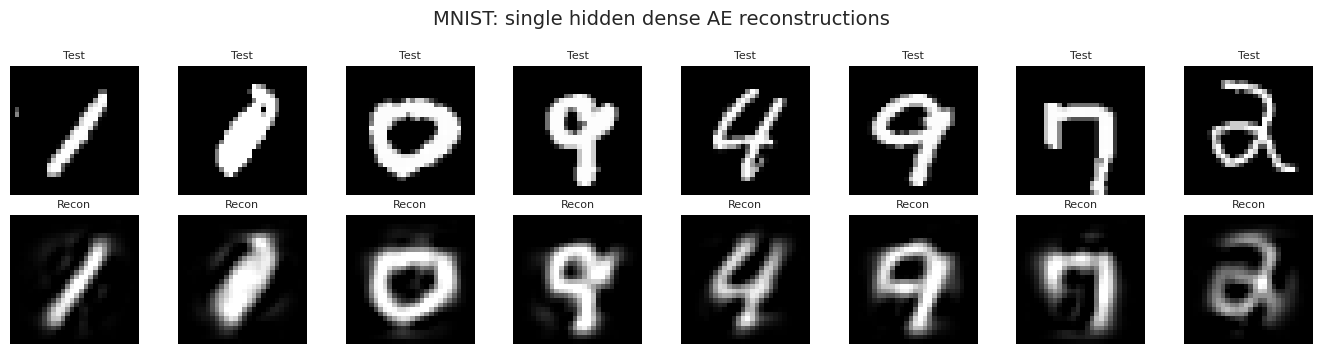

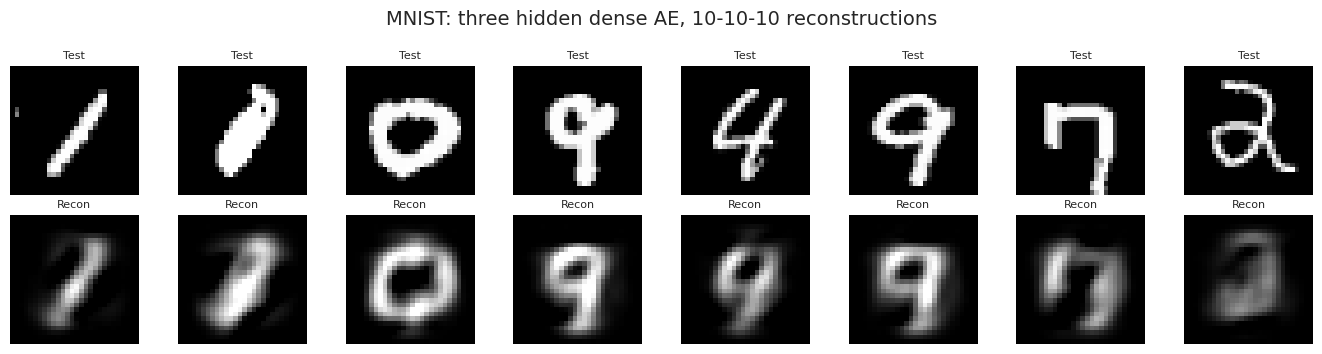

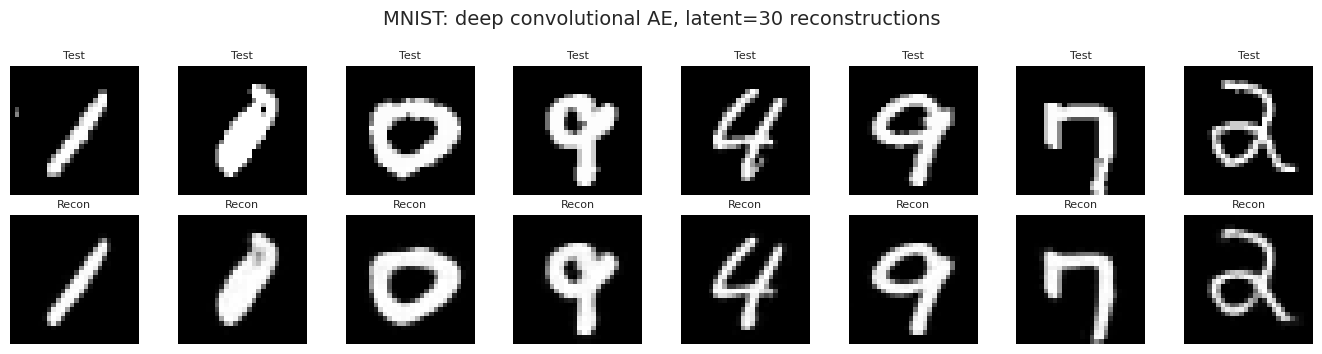

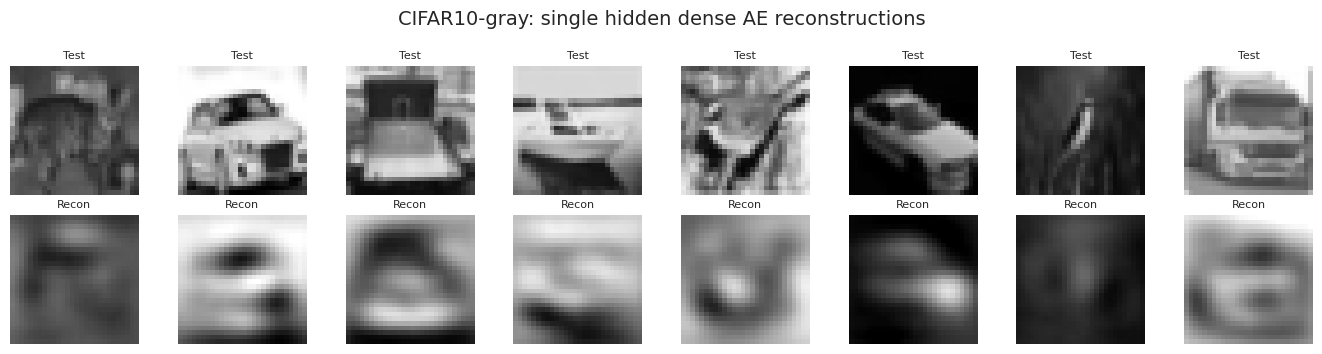

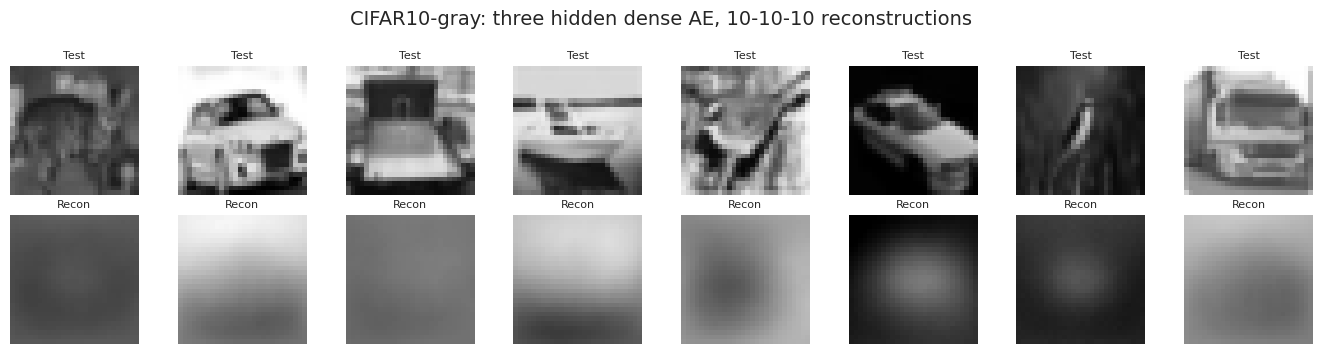

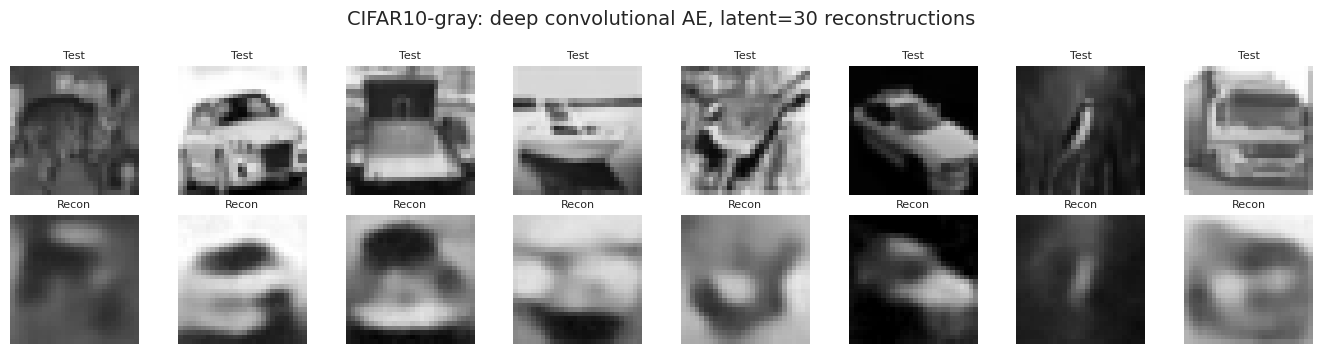

In [ ]:
for ds in datasets:
    for key, title in [
        ("single", "single hidden dense AE"),
        ("three", "three hidden dense AE, 10-10-10"),
        ("conv", "deep convolutional AE, latent=30"),
    ]:
        recon = task3_models[(ds.name, key)]["recon_50_200"]
        plot_reconstruction_examples(ds.x_test_flat_50_200, recon, f"{ds.name}: {title} reconstructions")



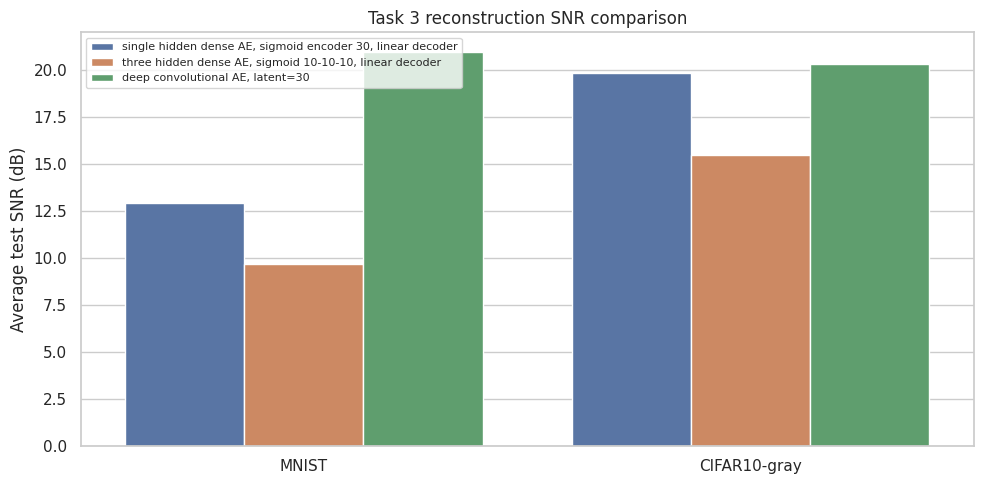

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=task3_results, x="dataset", y="average_test_snr_db", hue="method")
plt.title("Task 3 reconstruction SNR comparison")
plt.ylabel("Average test SNR (dB)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()



**Task 3 comments.**

The convolutional autoencoder is expected to achieve the highest SNR because convolutional filters exploit spatial
locality and weight sharing. The single hidden layer dense autoencoder with only 30 sigmoid hidden nodes is a much
stronger bottleneck and ignores image geometry. The three-hidden-layer dense model uses the same total hidden-node
budget split as 10-10-10, so the effective bottleneck is only 10 dimensions; it normally reconstructs worse than the
30-node single hidden layer model, especially for gray CIFAR10. MNIST is usually easier to reconstruct than CIFAR10
because digits are sparse and structurally simpler.



# Final Summary Tables



In [ ]:
print("Task 1: PCA and randomized PCA")
display(task1_results)

print("Task 1: top 30 eigenvalues")
display(task1_top30_eigenvalues)

print("Task 2: PCA versus tied linear AE classification and SNR")
display(
    pd.concat(
        [
            task1_results.query("method == 'standard PCA'")[
                ["dataset", "method", "components", "accuracy", "macro_auc_ovr", "average_test_snr_db"]
            ],
            task2_results,
        ],
        ignore_index=True,
    )
)

print("Task 2: quantitative component relationship")
display(component_comparison)

print("Task 3: nonlinear autoencoder SNR")
display(task3_results)



Task 1: PCA and randomized PCA


,dataset,method,components,accuracy,macro_auc_ovr,validation_accuracy,best_C,explained_variance_ratio_sum,average_test_snr_db
0,MNIST,standard PCA,30,0.893714,0.990301,0.892286,0.30,0.731536,12.572200
1,MNIST,randomized PCA,30,0.893571,0.990231,0.891929,0.03,0.731481,12.571399
2,CIFAR10-gray,standard PCA,30,0.306833,0.729708,0.304750,1.00,0.849658,20.001223
3,CIFAR10-gray,randomized PCA,30,0.307500,0.729693,0.304083,0.01,0.849626,20.001208


Task 1: top 30 eigenvalues


,dataset,method,principal_component,eigenvalue,explained_variance_ratio
0,MNIST,standard PCA,1,115333.320312,0.097197
1,MNIST,standard PCA,2,84967.710938,0.071606
2,MNIST,standard PCA,3,72919.406250,0.061453
3,MNIST,standard PCA,4,64177.621094,0.054086
4,MNIST,standard PCA,5,57887.746094,0.048785
...,...,...,...,...,...
115,CIFAR10-gray,randomized PCA,26,4224.890625,0.004475
116,CIFAR10-gray,randomized PCA,27,3719.742920,0.003940
117,CIFAR10-gray,randomized PCA,28,3548.849121,0.003759
118,CIFAR10-gray,randomized PCA,29,3444.521240,0.003648


Task 2: PCA versus tied linear AE classification and SNR


,dataset,method,components,accuracy,macro_auc_ovr,average_test_snr_db,validation_accuracy,best_C
0,MNIST,standard PCA,30,0.893714,0.990301,12.572200,NaN,NaN
1,CIFAR10-gray,standard PCA,30,0.306833,0.729708,20.001223,NaN,NaN
2,MNIST,tied linear AE features,30,0.891000,0.989867,11.246278,0.890071,10.00
3,CIFAR10-gray,tied linear AE features,30,0.305167,0.729332,19.991271,0.304500,0.01


Task 2: quantitative component relationship


,dataset,comparison_space,mean_matched_abs_cosine,median_matched_abs_cosine,min_matched_abs_cosine,mean_subspace_singular_value,max_principal_angle_deg
0,MNIST,Task 1 raw PCA vs AE raw-equivalent,0.030549,0.011095,0.000110,0.047469,89.996773
1,MNIST,standardized PCA vs AE,0.999829,0.999899,0.999099,0.999881,5.679926
2,CIFAR10-gray,Task 1 raw PCA vs AE raw-equivalent,0.905538,0.945882,0.754688,0.987276,32.957351
3,CIFAR10-gray,standardized PCA vs AE,0.999959,0.999962,0.999926,0.999960,1.826385


Task 3: nonlinear autoencoder SNR


,dataset,method,average_test_snr_db
0,MNIST,"single hidden dense AE, sigmoid encoder 30, li...",12.938472
1,MNIST,"three hidden dense AE, sigmoid 10-10-10, linea...",9.661777
2,MNIST,"deep convolutional AE, latent=30",20.972070
3,CIFAR10-gray,"single hidden dense AE, sigmoid encoder 30, li...",19.835798
4,CIFAR10-gray,"three hidden dense AE, sigmoid 10-10-10, linea...",15.498728
5,CIFAR10-gray,"deep convolutional AE, latent=30",20.318018


In [ ]:
def print_final_observations():
    print("Final observations generated from the current run")
    for ds_name in task1_results["dataset"].unique():
        std = task1_results[(task1_results["dataset"] == ds_name) & (task1_results["method"] == "standard PCA")].iloc[0]
        rnd = task1_results[(task1_results["dataset"] == ds_name) & (task1_results["method"] == "randomized PCA")].iloc[0]
        ae = task2_results[task2_results["dataset"] == ds_name].iloc[0]
        comp = component_comparison[
            (component_comparison["dataset"] == ds_name)
            & (component_comparison["comparison_space"] == "standardized PCA vs AE")
        ].iloc[0]
        single = task3_results[(task3_results["dataset"] == ds_name) & task3_results["method"].str.contains("single hidden", regex=False)].iloc[0]
        three = task3_results[(task3_results["dataset"] == ds_name) & task3_results["method"].str.contains("three hidden", regex=False)].iloc[0]
        conv = task3_results[(task3_results["dataset"] == ds_name) & task3_results["method"].str.contains("convolutional", regex=False)].iloc[0]

        print(f"\n{ds_name}")
        print(f"  Task 1 PCA       : acc={std['accuracy']:.4f}, macro AUC={std['macro_auc_ovr']:.4f}, SNR={std['average_test_snr_db']:.2f} dB")
        print(f"  Task 1 randomized: acc={rnd['accuracy']:.4f}, macro AUC={rnd['macro_auc_ovr']:.4f}, SNR={rnd['average_test_snr_db']:.2f} dB")
        print(f"  Task 2 tied AE   : acc={ae['accuracy']:.4f}, macro AUC={ae['macro_auc_ovr']:.4f}, SNR={ae['average_test_snr_db']:.2f} dB")
        print(f"  PCA-AE std-space : mean matched |cos|={comp['mean_matched_abs_cosine']:.4f}, max principal angle={comp['max_principal_angle_deg']:.2f} degrees")
        print(f"  Task 3 single AE : SNR={single['average_test_snr_db']:.2f} dB")
        print(f"  Task 3 10-10-10  : SNR={three['average_test_snr_db']:.2f} dB")
        print(f"  Task 3 conv AE   : SNR={conv['average_test_snr_db']:.2f} dB")

    print("\nConclusion: randomized PCA should closely match standard PCA; the tied linear AE should recover a PCA-like subspace; "
          "and the convolutional AE is expected to reconstruct best because it uses spatial structure. "
          "The PCA-AE relationship should be judged primarily in the standardized Task 2 space.")


print_final_observations()


Final observations generated from the current run

MNIST
  Task 1 PCA       : acc=0.8937, macro AUC=0.9903, SNR=12.57 dB
  Task 1 randomized: acc=0.8936, macro AUC=0.9902, SNR=12.57 dB
  Task 2 tied AE   : acc=0.8910, macro AUC=0.9899, SNR=11.25 dB
  PCA-AE std-space : mean matched |cos|=0.9998, max principal angle=5.68 degrees
  Task 3 single AE : SNR=12.94 dB
  Task 3 10-10-10  : SNR=9.66 dB
  Task 3 conv AE   : SNR=20.97 dB

CIFAR10-gray
  Task 1 PCA       : acc=0.3068, macro AUC=0.7297, SNR=20.00 dB
  Task 1 randomized: acc=0.3075, macro AUC=0.7297, SNR=20.00 dB
  Task 2 tied AE   : acc=0.3052, macro AUC=0.7293, SNR=19.99 dB
  PCA-AE std-space : mean matched |cos|=1.0000, max principal angle=1.83 degrees
  Task 3 single AE : SNR=19.84 dB
  Task 3 10-10-10  : SNR=15.50 dB
  Task 3 conv AE   : SNR=20.32 dB

Conclusion: randomized PCA should closely match standard PCA; the tied linear AE should recover a PCA-like subspace; and the convolutional AE is expected to reconstruct best becau